<a href="https://colab.research.google.com/github/Montasir00/Ml_final_project/blob/tabby/14-4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Final Project**

Team members:
1. Pham Gia Khiem - 551026 (Vietnam)
2. Mohammed Hassan – 541140 (Bangladesh)
3. Fazlur Rahman - 541927 (Bangladesh)

# I. UNDERSTANDING THE DATASET

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import MinMaxScaler

from scipy import stats
from sklearn.model_selection import train_test_split

from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import RFE
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.ensemble import VotingClassifier
from sklearn.metrics import accuracy_score, roc_curve, auc
from sklearn.model_selection import cross_val_score, KFold, StratifiedKFold
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.decomposition import PCA
import shap

In [ ]:
df = pd.read_csv('/content/final_project_dataset_complete.csv')
df

,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,category_1,category_2,target
0,0.496714,1.146509,-0.648521,0.833005,0.784920,-2.209437,-1.300105,-2.242241,Above Average,Region C,1
1,-0.138264,-0.061846,NaN,0.403768,0.704674,-2.498565,-1.339227,-1.942298,Below Average,Region A,0
2,0.647689,1.395115,-0.764126,1.708266,-0.250029,1.956259,1.190238,1.503559,High,Region C,1
3,1.523030,2.657560,-2.461653,2.649051,0.882201,3.445638,2.120913,3.409035,High,Region B,1
4,-0.234153,-0.499391,0.576097,-0.441656,0.610601,0.211425,0.935759,-0.401463,Below Average,Region C,0
...,...,...,...,...,...,...,...,...,...,...,...
8995,0.101630,0.400250,NaN,-0.019412,-0.063150,0.077627,0.540975,-0.169030,Above Average,Region A,0
8996,1.167218,2.177774,-1.716067,1.994835,0.350043,-0.544915,0.089050,-0.944220,High,Region C,1
8997,1.588447,3.333945,-2.615488,3.476880,-0.933276,2.027658,0.239583,1.951491,High,Region C,1
8998,-0.684987,-1.599835,1.063341,-1.252109,-0.724001,2.228943,0.989794,1.936476,Low,Region B,0


In [ ]:
df.head()

,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,category_1,category_2,target
0,0.496714,1.146509,-0.648521,0.833005,0.784920,-2.209437,-1.300105,-2.242241,Above Average,Region C,1
1,-0.138264,-0.061846,NaN,0.403768,0.704674,-2.498565,-1.339227,-1.942298,Below Average,Region A,0
2,0.647689,1.395115,-0.764126,1.708266,-0.250029,1.956259,1.190238,1.503559,High,Region C,1
3,1.523030,2.657560,-2.461653,2.649051,0.882201,3.445638,2.120913,3.409035,High,Region B,1
4,-0.234153,-0.499391,0.576097,-0.441656,0.610601,0.211425,0.935759,-0.401463,Below Average,Region C,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9000 entries, 0 to 8999
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   feature_1   9000 non-null   float64
 1   feature_2   9000 non-null   float64
 2   feature_3   8600 non-null   float64
 3   feature_4   9000 non-null   float64
 4   feature_5   9000 non-null   float64
 5   feature_6   8500 non-null   float64
 6   feature_7   9000 non-null   float64
 7   feature_8   9000 non-null   float64
 8   category_1  9000 non-null   object 
 9   category_2  9000 non-null   object 
 10  target      9000 non-null   int64  
dtypes: float64(8), int64(1), object(2)
memory usage: 773.6+ KB


In [ ]:
df.describe()

,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,target
count,9000.000000,9000.000000,8600.000000,9000.000000,9000.000000,8500.000000,9000.000000,9000.000000,9000.000000
mean,0.000427,0.003349,0.003235,-0.008481,-0.002177,-0.006447,0.000592,0.003348,0.475444
std,1.241318,2.508324,1.542901,2.061784,0.577415,1.981615,1.075064,2.043643,0.499424
min,-18.665400,-37.852816,-6.676680,-8.190124,-0.999791,-8.590782,-4.422265,-9.474989,0.000000
25%,-0.680062,-1.382610,-1.022085,-1.399928,-0.502614,-1.329040,-0.700078,-1.356620,0.000000
50%,-0.003938,-0.016698,0.005196,-0.019541,0.001695,-0.003137,-0.000097,-0.007584,0.000000
75%,0.680513,1.380228,1.038571,1.394151,0.497004,1.324897,0.731942,1.402024,1.000000
max,21.934496,47.603454,6.203055,8.189001,0.999914,6.803751,3.857219,7.572578,1.000000


In [ ]:
numerical_features = df.select_dtypes(include=['float64','int64'])

In [ ]:
numerical_features

,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,target
0,0.496714,1.146509,-0.648521,0.833005,0.784920,-2.209437,-1.300105,-2.242241,1
1,-0.138264,-0.061846,NaN,0.403768,0.704674,-2.498565,-1.339227,-1.942298,0
2,0.647689,1.395115,-0.764126,1.708266,-0.250029,1.956259,1.190238,1.503559,1
3,1.523030,2.657560,-2.461653,2.649051,0.882201,3.445638,2.120913,3.409035,1
4,-0.234153,-0.499391,0.576097,-0.441656,0.610601,0.211425,0.935759,-0.401463,0
...,...,...,...,...,...,...,...,...,...
8995,0.101630,0.400250,NaN,-0.019412,-0.063150,0.077627,0.540975,-0.169030,0
8996,1.167218,2.177774,-1.716067,1.994835,0.350043,-0.544915,0.089050,-0.944220,1
8997,1.588447,3.333945,-2.615488,3.476880,-0.933276,2.027658,0.239583,1.951491,1
8998,-0.684987,-1.599835,1.063341,-1.252109,-0.724001,2.228943,0.989794,1.936476,0


In [ ]:
numerical_features.head()

,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,target
0,0.496714,1.146509,-0.648521,0.833005,0.784920,-2.209437,-1.300105,-2.242241,1
1,-0.138264,-0.061846,NaN,0.403768,0.704674,-2.498565,-1.339227,-1.942298,0
2,0.647689,1.395115,-0.764126,1.708266,-0.250029,1.956259,1.190238,1.503559,1
3,1.523030,2.657560,-2.461653,2.649051,0.882201,3.445638,2.120913,3.409035,1
4,-0.234153,-0.499391,0.576097,-0.441656,0.610601,0.211425,0.935759,-0.401463,0


In [ ]:
categorical_features = df.select_dtypes(include=['object'])

In [ ]:
categorical_features.head()

,category_1,category_2
0,Above Average,Region C
1,Below Average,Region A
2,High,Region C
3,High,Region B
4,Below Average,Region C


In [ ]:
numerical_corr = numerical_features.corr()

In [ ]:
#Correlation Matrix
numerical_corr

,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,target
feature_1,1.000000,0.995360,-0.831705,0.831922,-0.015305,-0.010813,-0.010843,-0.004581,0.605940
feature_2,0.995360,1.000000,-0.823242,0.832002,-0.014715,-0.011519,-0.011393,-0.005394,0.606016
feature_3,-0.831705,-0.823242,1.000000,-0.957222,0.011309,0.003989,0.006042,0.001846,-0.704351
feature_4,0.831922,0.832002,-0.957222,1.000000,-0.003613,-0.000213,-0.001369,0.001202,0.694885
feature_5,-0.015305,-0.014715,0.011309,-0.003613,1.000000,-0.009365,0.252371,-0.012717,-0.007873
feature_6,-0.010813,-0.011519,0.003989,-0.000213,-0.009365,1.000000,0.921569,0.969998,0.001457
feature_7,-0.010843,-0.011393,0.006042,-0.001369,0.252371,0.921569,1.000000,0.894220,-0.002000
feature_8,-0.004581,-0.005394,0.001846,0.001202,-0.012717,0.969998,0.894220,1.000000,0.004658
target,0.605940,0.606016,-0.704351,0.694885,-0.007873,0.001457,-0.002000,0.004658,1.000000


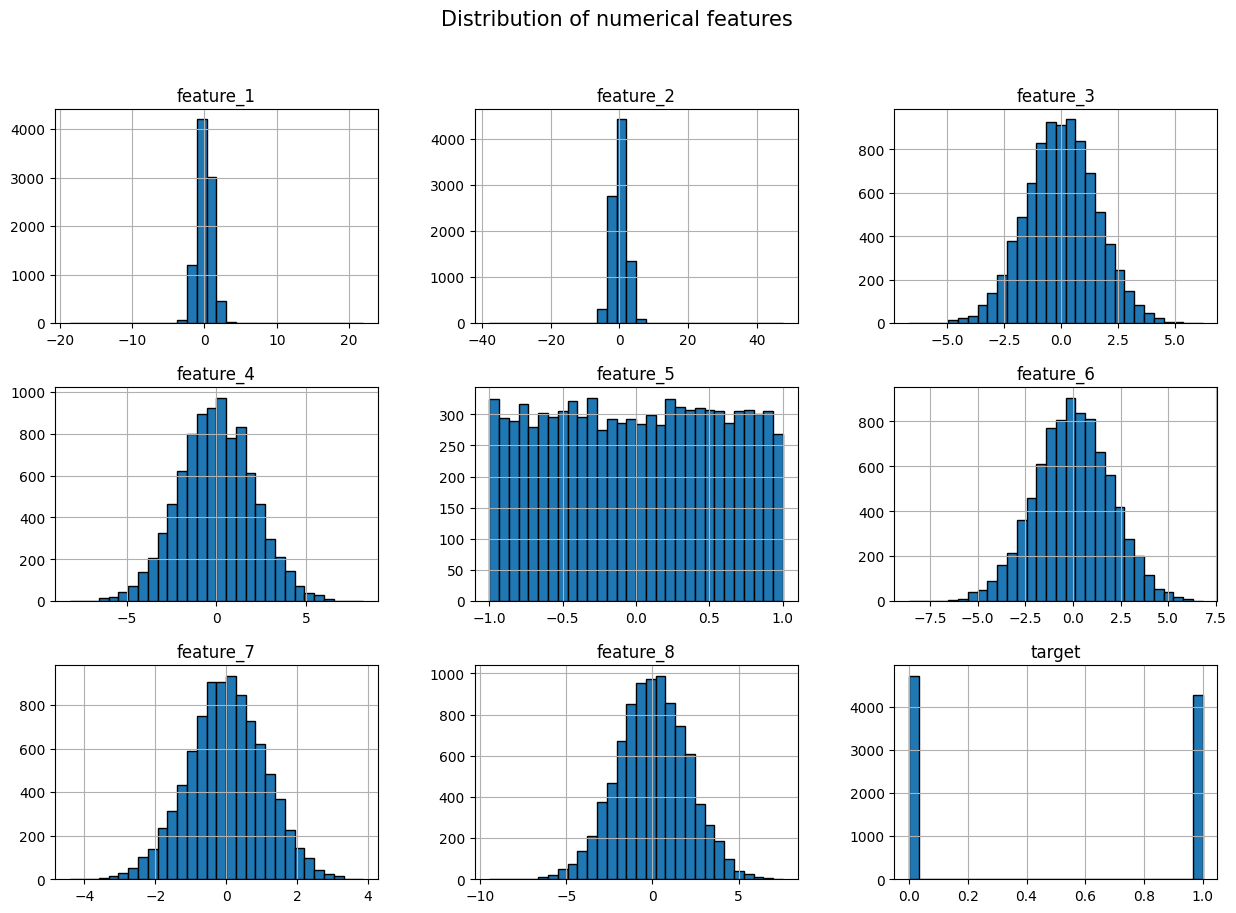

In [ ]:
#Historgram of distribution of numerical features
df.hist(bins=30, figsize=(15,10), edgecolor = 'black')
plt.suptitle("Distribution of numerical features", fontsize = 15)
plt.show()

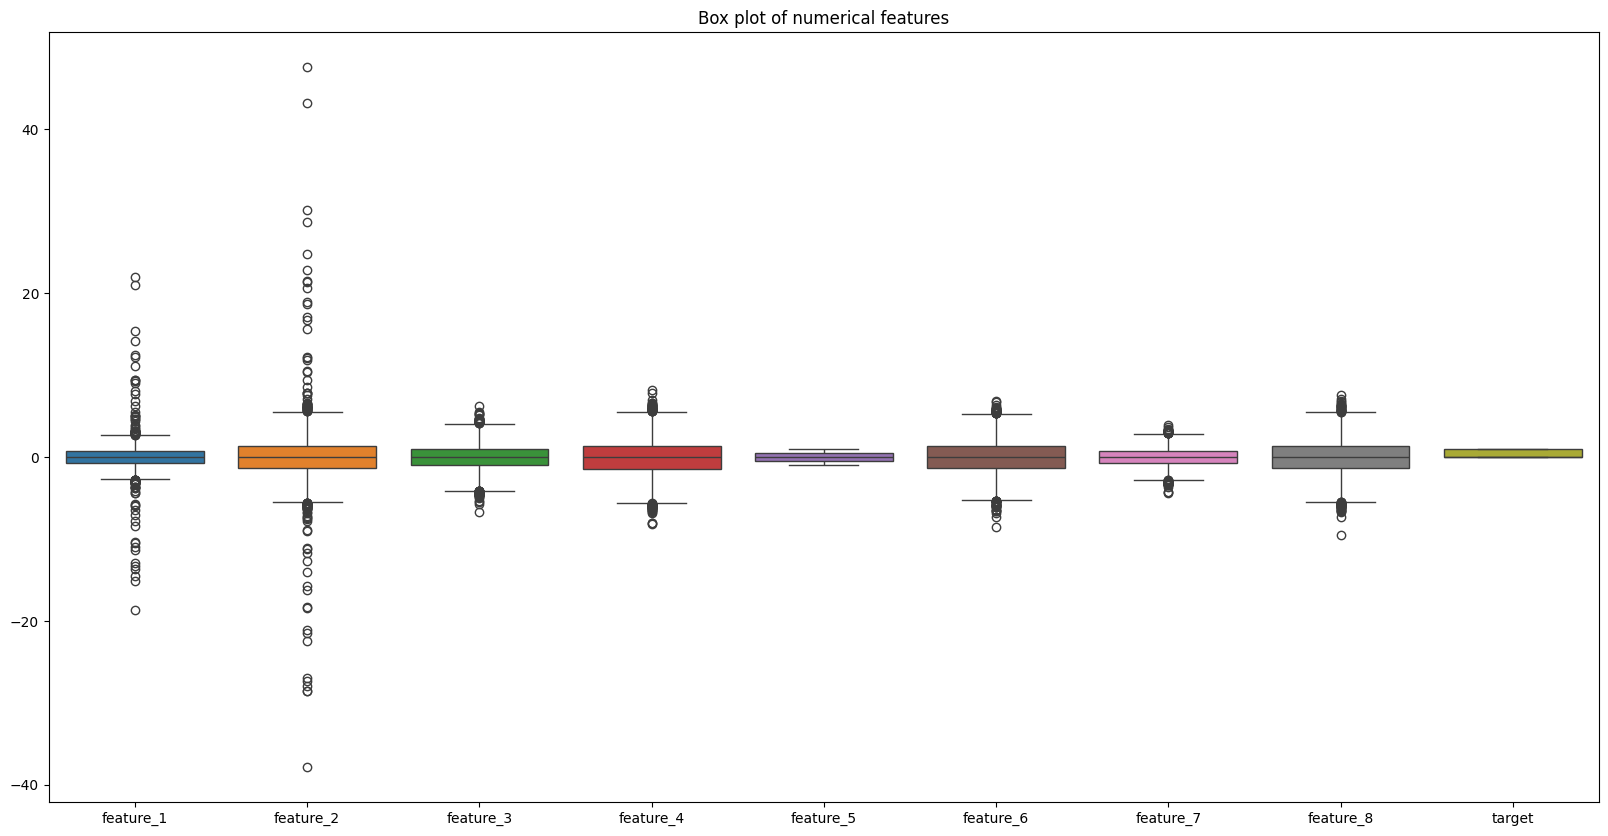

In [ ]:
#Box plot of distribution of numerical features
plt.figure(figsize=(20,10))
sns.boxplot(data=numerical_features)
plt.title('Box plot of numerical features')
plt.show()

<Figure size 2000x1000 with 0 Axes>

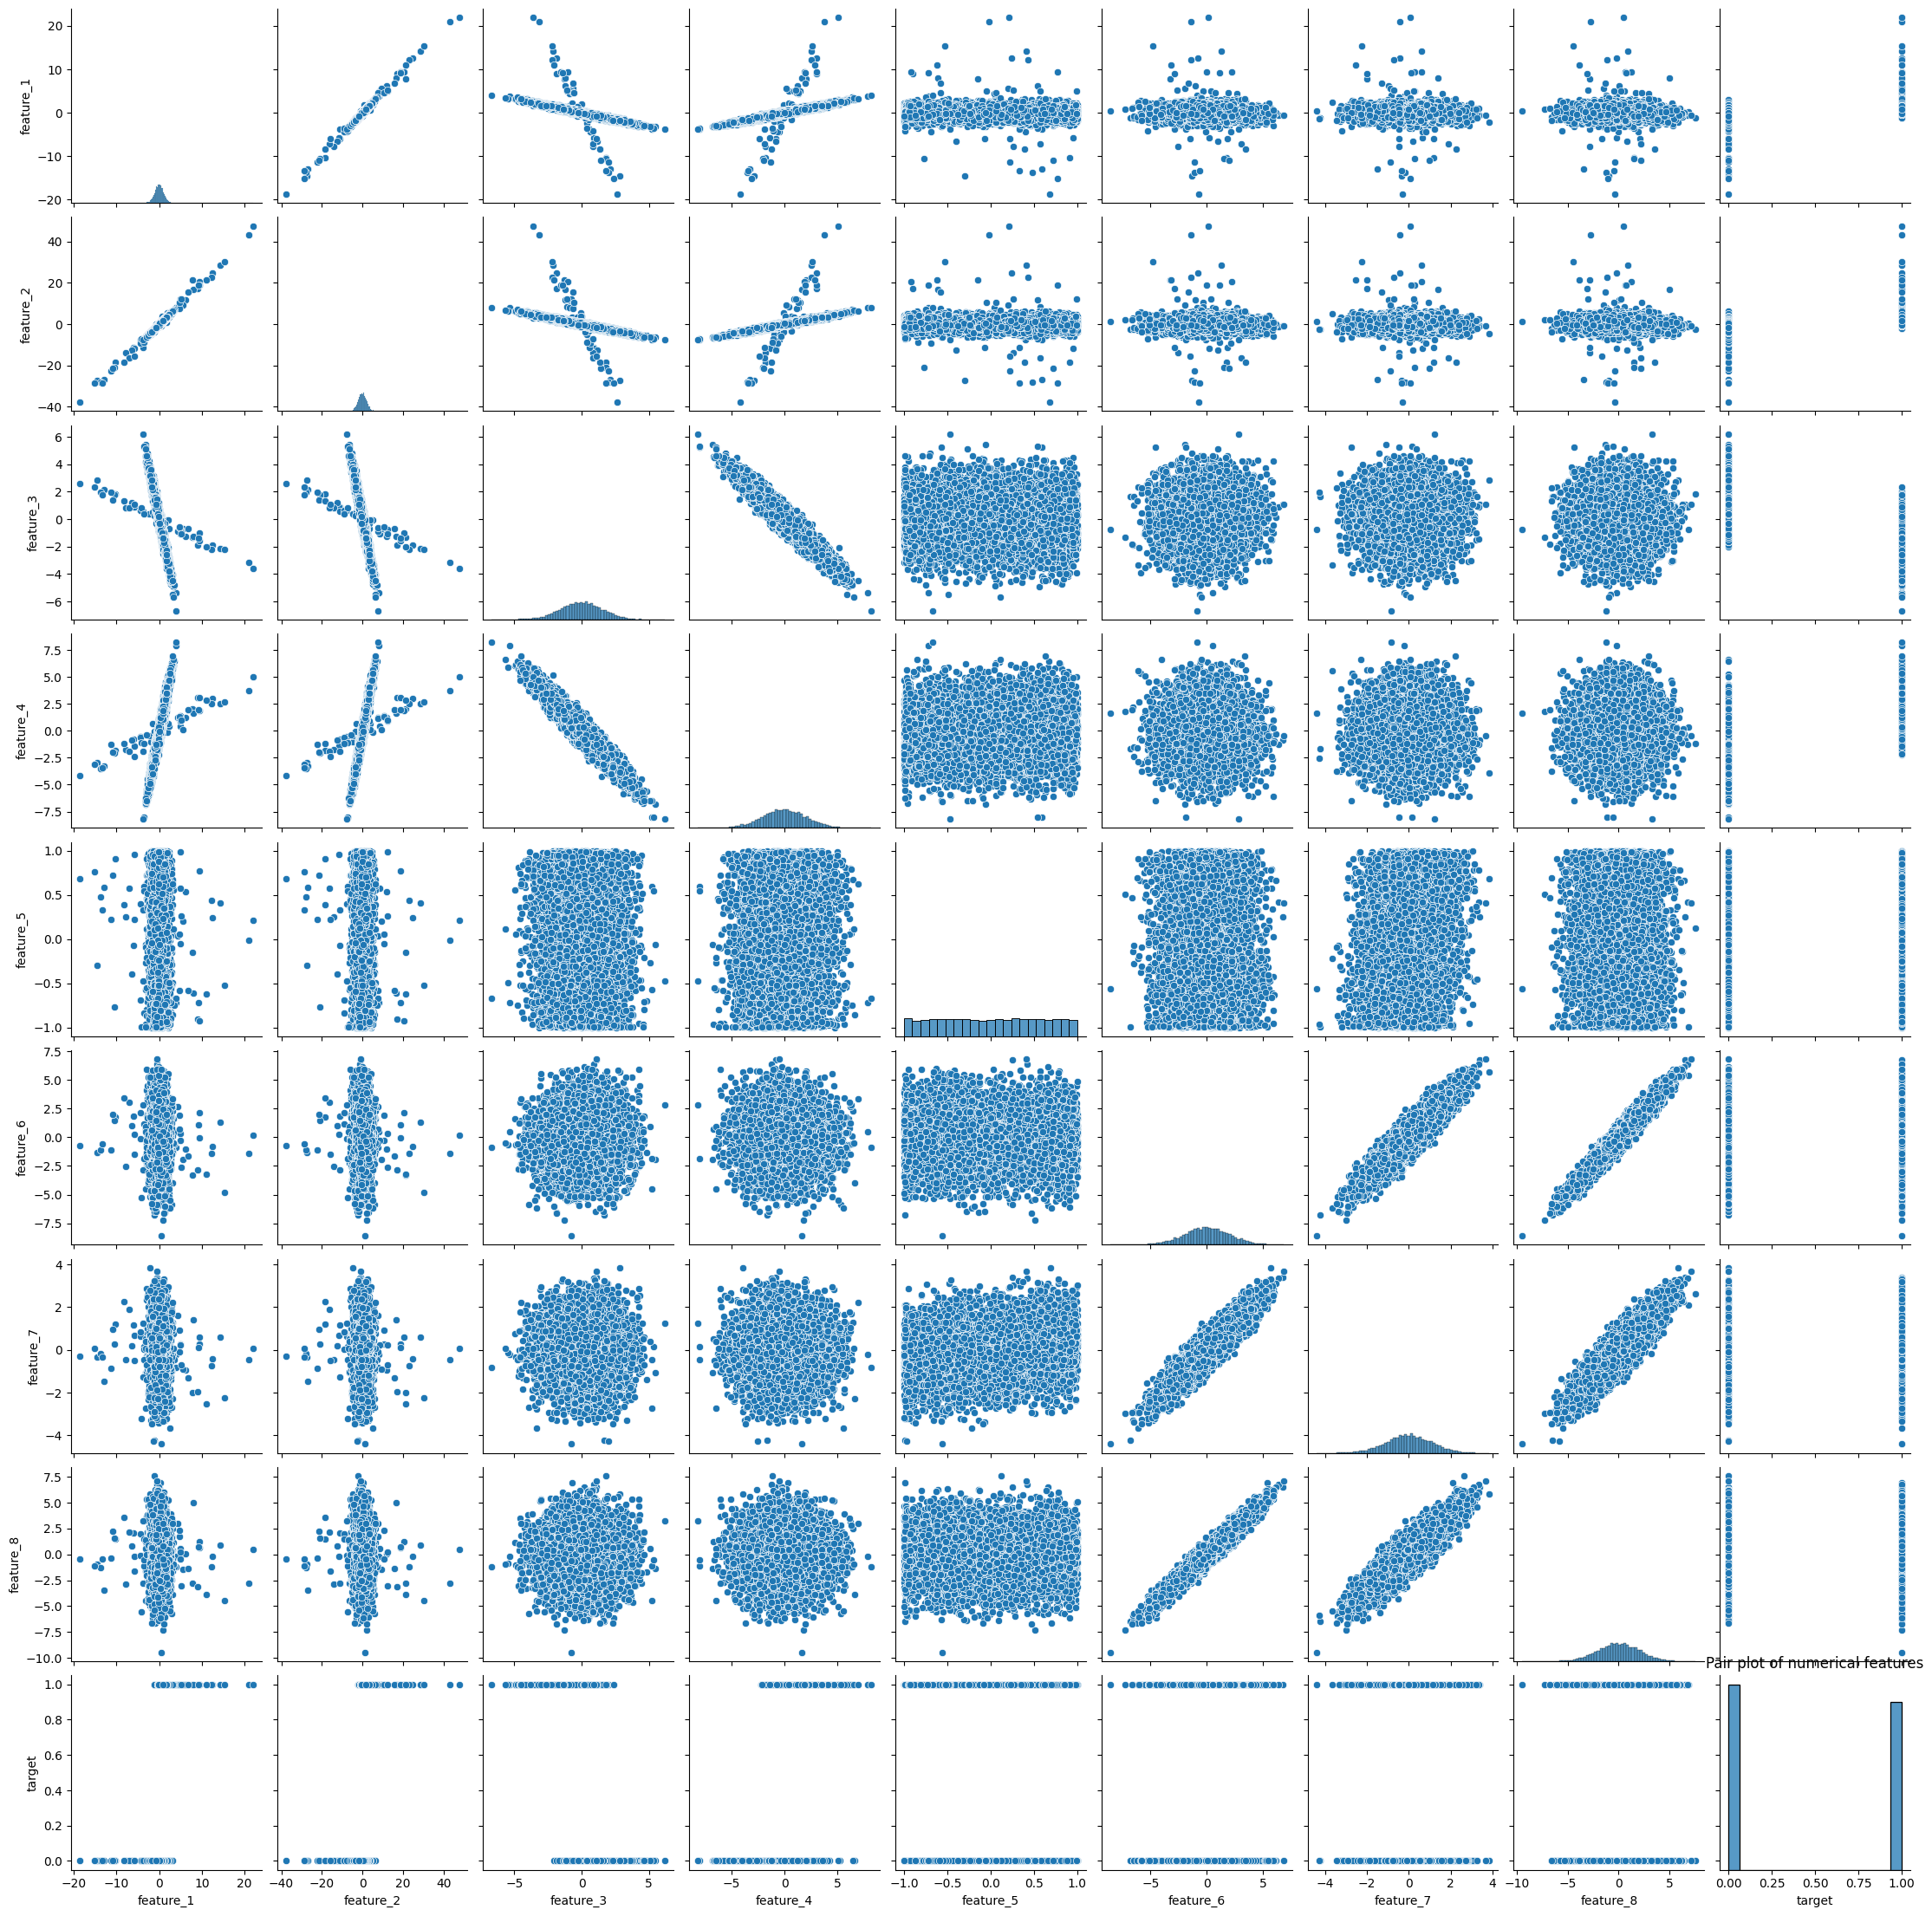

In [ ]:
plt.figure(figsize=(20,10))
sns.pairplot(df, hue=None)
plt.title('Pair plot of numerical features')
plt.show()

# II. DATA PREPROCESSING


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.isna().sum()

,0
feature_1,0
feature_2,0
feature_3,400
feature_4,0
feature_5,0
feature_6,500
feature_7,0
feature_8,0
category_1,0
category_2,0


In [ ]:
missing_values = df.isna().sum()
missing_values = missing_values[missing_values > 0]
print(missing_values)

feature_3    400
feature_6    500
dtype: int64


In [ ]:
imputer = SimpleImputer(missing_values=np.nan, strategy='median')
df['feature_3'] = imputer.fit_transform(df[['feature_3']])
df['feature_6'] = imputer.fit_transform(df[['feature_6']])

In [ ]:
df['feature_3'].isna().sum()
df['feature_6'].isna().sum()

np.int64(0)

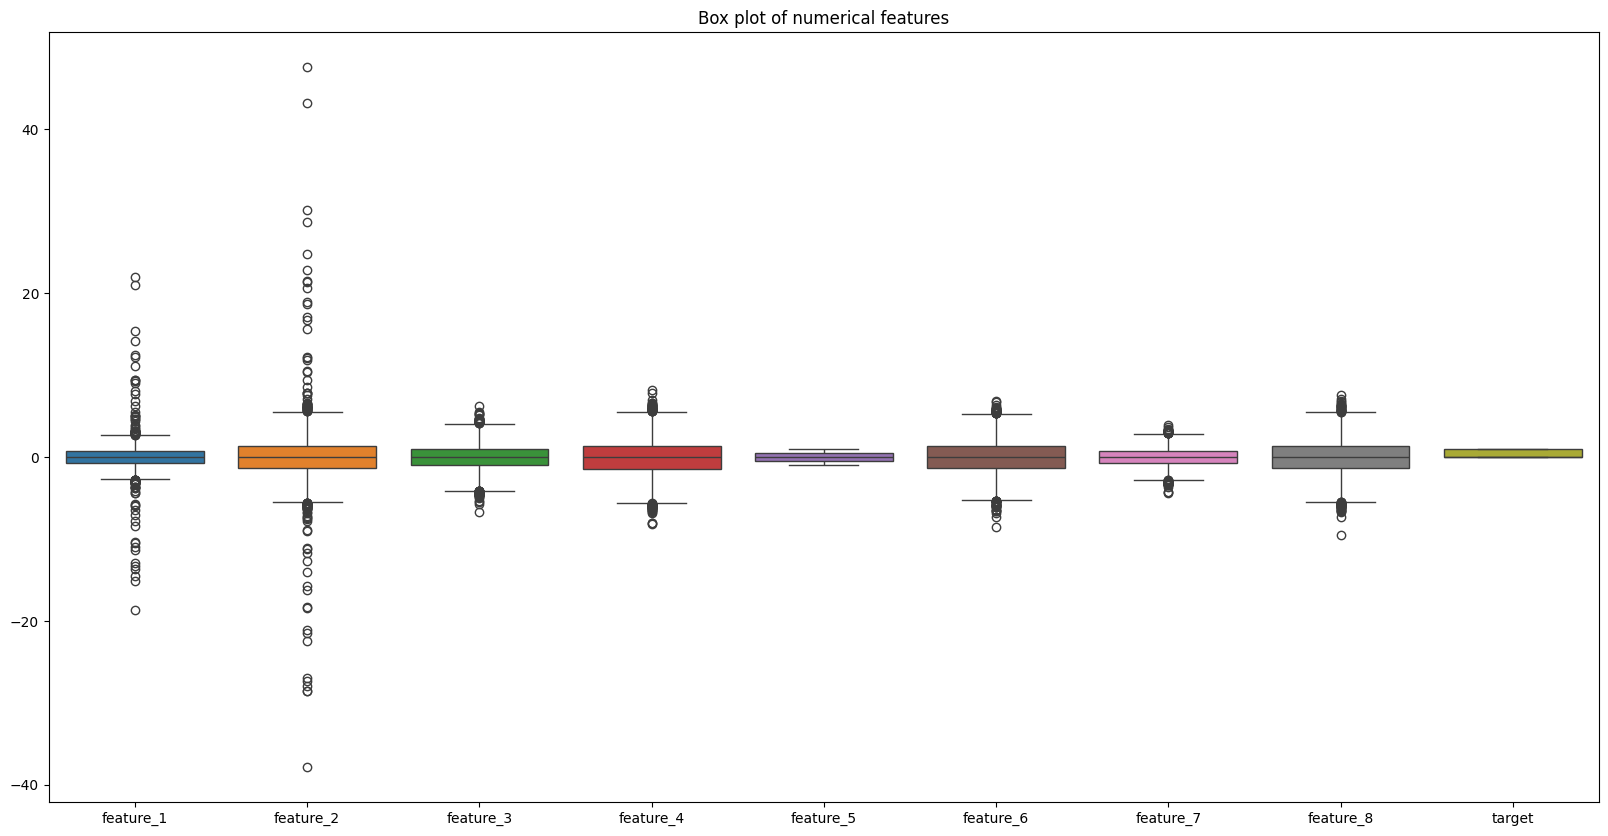

In [ ]:
plt.figure(figsize=(20,10))
plt.title('Box plot of numerical features')
sns.boxplot(data=numerical_features)
plt.show()

In [ ]:
def iqr_outliers(dataset, feature_name, multiplier= 1.5):
    Q1 = dataset[feature_name].quantile(0.25)
    Q3 = dataset[feature_name].quantile(0.75)
    IQR = Q3 - Q1

    lower_limit = Q1 - multiplier * IQR
    upper_limit = Q3 + multiplier * IQR

    outliers = dataset[(dataset[feature_name] < lower_limit) | (dataset[feature_name] > upper_limit)]

    return outliers, {'lower_limit': lower_limit, 'upper_limit': upper_limit}

outliers_detected = {}

for feature in numerical_features.columns:
    outliers, limits = iqr_outliers(numerical_features, feature)
    outliers_detected[feature] = {
        'count': len(outliers),
        'indices': outliers.index.tolist(),
        'limits': limits
    }

    print(f'Feature: {feature}')
    print(f'Number of outliers: {len(outliers)}')
    print(f'Lower limit: {limits["lower_limit"]}, Upper limit: {limits["upper_limit"]}')
    print(f'Outlier indices: {outliers.index.tolist()}')
    print('-' * 50)

Feature: feature_1
Number of outliers: 113
Lower limit: -2.7209235765, Upper limit: 2.7213741995
Outlier indices: [209, 262, 277, 469, 478, 496, 598, 774, 1061, 1101, 1400, 1445, 1539, 1591, 1615, 1785, 1957, 1971, 2024, 2035, 2093, 2218, 2228, 2305, 2336, 2442, 2458, 2506, 2521, 2884, 2895, 2947, 3017, 3152, 3227, 3241, 3245, 3336, 3454, 3510, 3569, 3716, 3872, 3982, 3986, 4026, 4029, 4033, 4047, 4091, 4198, 4207, 4265, 4359, 4531, 4617, 4635, 4639, 4725, 4779, 4784, 4870, 4997, 5157, 5224, 5316, 5416, 5488, 5587, 5642, 5649, 5673, 5773, 5796, 5846, 5907, 5935, 5998, 6350, 6408, 6628, 6693, 6738, 6747, 6891, 7060, 7140, 7178, 7223, 7290, 7305, 7330, 7441, 7498, 7611, 7624, 7677, 7839, 7851, 7858, 7872, 7874, 8024, 8067, 8165, 8180, 8200, 8248, 8283, 8354, 8630, 8714, 8726]
--------------------------------------------------
Feature: feature_2
Number of outliers: 106
Lower limit: -5.5268680488749995, Upper limit: 5.524485932125
Outlier indices: [209, 262, 277, 469, 478, 496, 598, 774, 1

In [ ]:
df_1 = df.copy()
for feature, values in outliers_detected.items():
    outlier_indices = values['indices']
    median_value = df_1[feature].median()
    df_1.loc[outlier_indices, feature] = median_value
    print(f"Feature: {feature}")
    print(f"Replaced outliers in indices: {outlier_indices}")
    print('-' * 50)

Feature: feature_1
Replaced outliers in indices: [209, 262, 277, 469, 478, 496, 598, 774, 1061, 1101, 1400, 1445, 1539, 1591, 1615, 1785, 1957, 1971, 2024, 2035, 2093, 2218, 2228, 2305, 2336, 2442, 2458, 2506, 2521, 2884, 2895, 2947, 3017, 3152, 3227, 3241, 3245, 3336, 3454, 3510, 3569, 3716, 3872, 3982, 3986, 4026, 4029, 4033, 4047, 4091, 4198, 4207, 4265, 4359, 4531, 4617, 4635, 4639, 4725, 4779, 4784, 4870, 4997, 5157, 5224, 5316, 5416, 5488, 5587, 5642, 5649, 5673, 5773, 5796, 5846, 5907, 5935, 5998, 6350, 6408, 6628, 6693, 6738, 6747, 6891, 7060, 7140, 7178, 7223, 7290, 7305, 7330, 7441, 7498, 7611, 7624, 7677, 7839, 7851, 7858, 7872, 7874, 8024, 8067, 8165, 8180, 8200, 8248, 8283, 8354, 8630, 8714, 8726]
--------------------------------------------------
Feature: feature_2
Replaced outliers in indices: [209, 262, 277, 469, 478, 496, 598, 774, 1061, 1101, 1400, 1445, 1591, 1615, 1785, 1957, 1971, 2024, 2093, 2218, 2228, 2305, 2336, 2442, 2458, 2506, 2895, 2947, 3017, 3152, 3227, 3

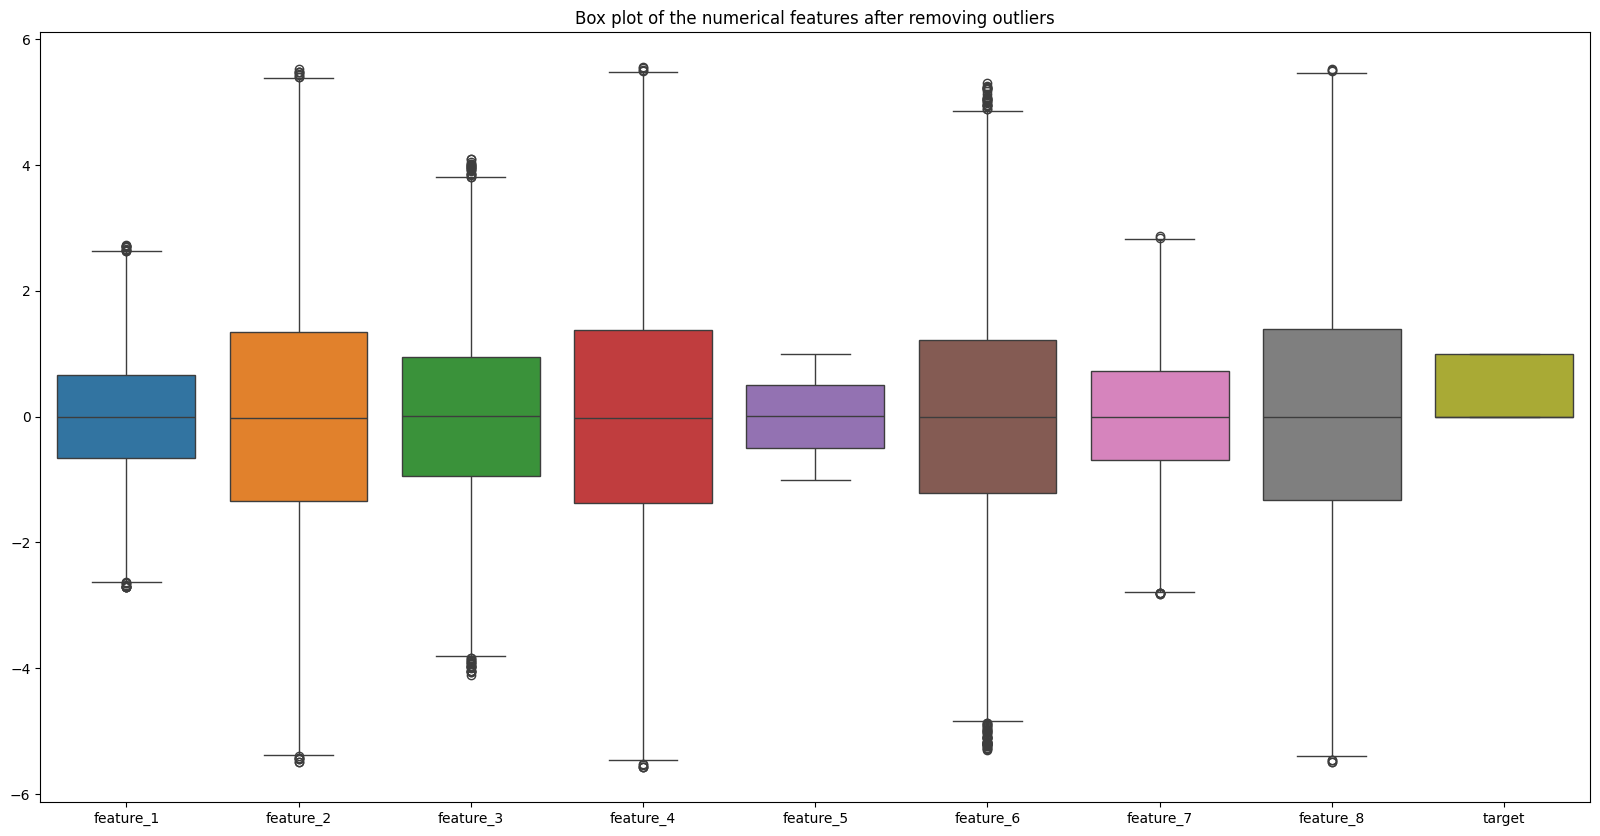

In [ ]:
plt.figure(figsize=(20, 10))
plt.title('Box plot of the numerical features after removing outliers')
sns.boxplot(data=df_1)
plt.show()

In [ ]:
df_1.describe()

,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,target
count,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000
mean,-0.000672,0.002354,0.005962,-0.010226,-0.002177,-0.004937,0.006010,0.010578,0.475444
std,0.971927,1.959564,1.448882,1.986669,0.577415,1.865959,1.038181,1.980097,0.499424
min,-2.712613,-5.486925,-4.104379,-5.569645,-0.999791,-5.299373,-2.819977,-5.490152,0.000000
25%,-0.657194,-1.346706,-0.950363,-1.377240,-0.502614,-1.211517,-0.684357,-1.329677,0.000000
50%,-0.003938,-0.016698,0.005196,-0.019541,0.001695,-0.003137,-0.000097,-0.007584,0.000000
75%,0.659561,1.343450,0.954145,1.368650,0.497004,1.218900,0.720851,1.386503,1.000000
max,2.720169,5.516173,4.096764,5.552331,0.999914,5.293819,2.876070,5.529430,1.000000


In [ ]:
categorical_features.head()

,category_1,category_2
0,Above Average,Region C
1,Below Average,Region A
2,High,Region C
3,High,Region B
4,Below Average,Region C


In [ ]:
#Encoding categorical variables
from sklearn.preprocessing import LabelEncoder
df_2 = df_1.copy()

label_encoder = LabelEncoder()
df_2['category_1_encoded'] = label_encoder.fit_transform(df_2['category_1'])
df_one_hot = pd.get_dummies(df_2['category_2'])
df_one_hot = df_one_hot.astype(int)
df_2 = pd.concat([df_2, df_one_hot], axis=1)

df_2.drop(columns=['category_1','category_2'], inplace=True)
df_2.head()

,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,target,category_1_encoded,Region A,Region B,Region C
0,0.496714,1.146509,-0.648521,0.833005,0.784920,-2.209437,-1.300105,-2.242241,1,0,0,0,1
1,-0.138264,-0.061846,0.005196,0.403768,0.704674,-2.498565,-1.339227,-1.942298,0,1,1,0,0
2,0.647689,1.395115,-0.764126,1.708266,-0.250029,1.956259,1.190238,1.503559,1,2,0,0,1
3,1.523030,2.657560,-2.461653,2.649051,0.882201,3.445638,2.120913,3.409035,1,2,0,1,0
4,-0.234153,-0.499391,0.576097,-0.441656,0.610601,0.211425,0.935759,-0.401463,0,1,0,0,1


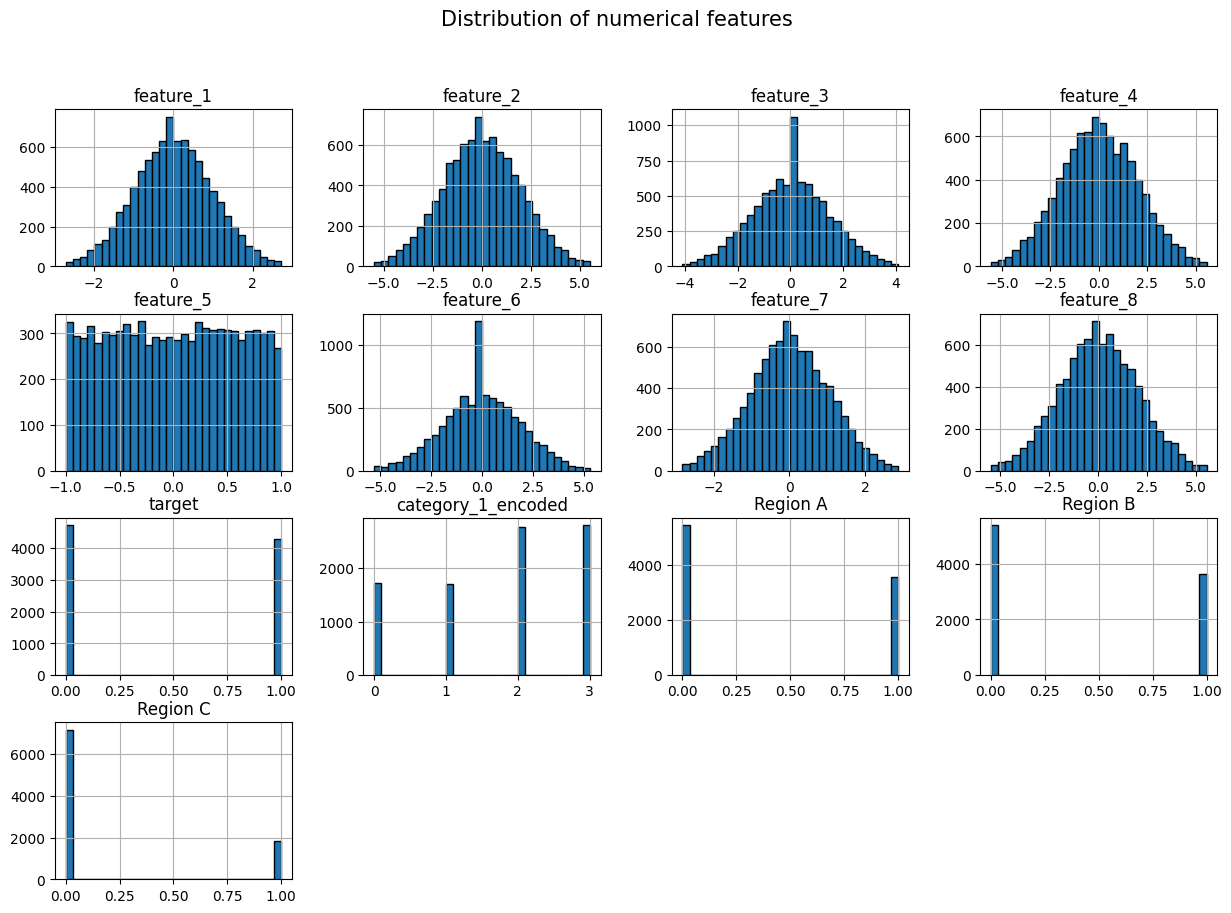

In [ ]:
df_2.hist(bins = 30, figsize=(15,10), edgecolor = 'black')
plt.suptitle("Distribution of numerical features", fontsize = 15)
plt.show()

In [ ]:
df_2.describe()

,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,target,category_1_encoded,Region A,Region B,Region C
count,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000
mean,-0.000672,0.002354,0.005962,-0.010226,-0.002177,-0.004937,0.006010,0.010578,0.475444,1.737778,0.394556,0.402000,0.203444
std,0.971927,1.959564,1.448882,1.986669,0.577415,1.865959,1.038181,1.980097,0.499424,1.095463,0.488782,0.490329,0.402583
min,-2.712613,-5.486925,-4.104379,-5.569645,-0.999791,-5.299373,-2.819977,-5.490152,0.000000,0.000000,0.000000,0.000000,0.000000
25%,-0.657194,-1.346706,-0.950363,-1.377240,-0.502614,-1.211517,-0.684357,-1.329677,0.000000,1.000000,0.000000,0.000000,0.000000
50%,-0.003938,-0.016698,0.005196,-0.019541,0.001695,-0.003137,-0.000097,-0.007584,0.000000,2.000000,0.000000,0.000000,0.000000
75%,0.659561,1.343450,0.954145,1.368650,0.497004,1.218900,0.720851,1.386503,1.000000,3.000000,1.000000,1.000000,0.000000
max,2.720169,5.516173,4.096764,5.552331,0.999914,5.293819,2.876070,5.529430,1.000000,3.000000,1.000000,1.000000,1.000000


In [ ]:
# export cleaned dataset
df_2.to_csv('C:\depression analysis\Machine Learning\final project\cleaned_dataset.csv')

# III. EDA (EXPLORATORY DATA ANALYSIS)




In [ ]:
df_2.describe()

,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,target,category_1_encoded,Region A,Region B,Region C
count,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000
mean,-0.000672,0.002354,0.005962,-0.010226,-0.002177,-0.004937,0.006010,0.010578,0.475444,1.737778,0.394556,0.402000,0.203444
std,0.971927,1.959564,1.448882,1.986669,0.577415,1.865959,1.038181,1.980097,0.499424,1.095463,0.488782,0.490329,0.402583
min,-2.712613,-5.486925,-4.104379,-5.569645,-0.999791,-5.299373,-2.819977,-5.490152,0.000000,0.000000,0.000000,0.000000,0.000000
25%,-0.657194,-1.346706,-0.950363,-1.377240,-0.502614,-1.211517,-0.684357,-1.329677,0.000000,1.000000,0.000000,0.000000,0.000000
50%,-0.003938,-0.016698,0.005196,-0.019541,0.001695,-0.003137,-0.000097,-0.007584,0.000000,2.000000,0.000000,0.000000,0.000000
75%,0.659561,1.343450,0.954145,1.368650,0.497004,1.218900,0.720851,1.386503,1.000000,3.000000,1.000000,1.000000,0.000000
max,2.720169,5.516173,4.096764,5.552331,0.999914,5.293819,2.876070,5.529430,1.000000,3.000000,1.000000,1.000000,1.000000


In [ ]:
df_2.head()

,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,target,category_1_encoded,Region A,Region B,Region C
0,0.496714,1.146509,-0.648521,0.833005,0.784920,-2.209437,-1.300105,-2.242241,1,0,0,0,1
1,-0.138264,-0.061846,0.005196,0.403768,0.704674,-2.498565,-1.339227,-1.942298,0,1,1,0,0
2,0.647689,1.395115,-0.764126,1.708266,-0.250029,1.956259,1.190238,1.503559,1,2,0,0,1
3,1.523030,2.657560,-2.461653,2.649051,0.882201,3.445638,2.120913,3.409035,1,2,0,1,0
4,-0.234153,-0.499391,0.576097,-0.441656,0.610601,0.211425,0.935759,-0.401463,0,1,0,0,1


In [ ]:
numerical_feas = df_2.select_dtypes(include=['float64','int64'])
numerical_feas.head()

,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,target,category_1_encoded,Region A,Region B,Region C
0,0.496714,1.146509,-0.648521,0.833005,0.784920,-2.209437,-1.300105,-2.242241,1,0,0,0,1
1,-0.138264,-0.061846,0.005196,0.403768,0.704674,-2.498565,-1.339227,-1.942298,0,1,1,0,0
2,0.647689,1.395115,-0.764126,1.708266,-0.250029,1.956259,1.190238,1.503559,1,2,0,0,1
3,1.523030,2.657560,-2.461653,2.649051,0.882201,3.445638,2.120913,3.409035,1,2,0,1,0
4,-0.234153,-0.499391,0.576097,-0.441656,0.610601,0.211425,0.935759,-0.401463,0,1,0,0,1


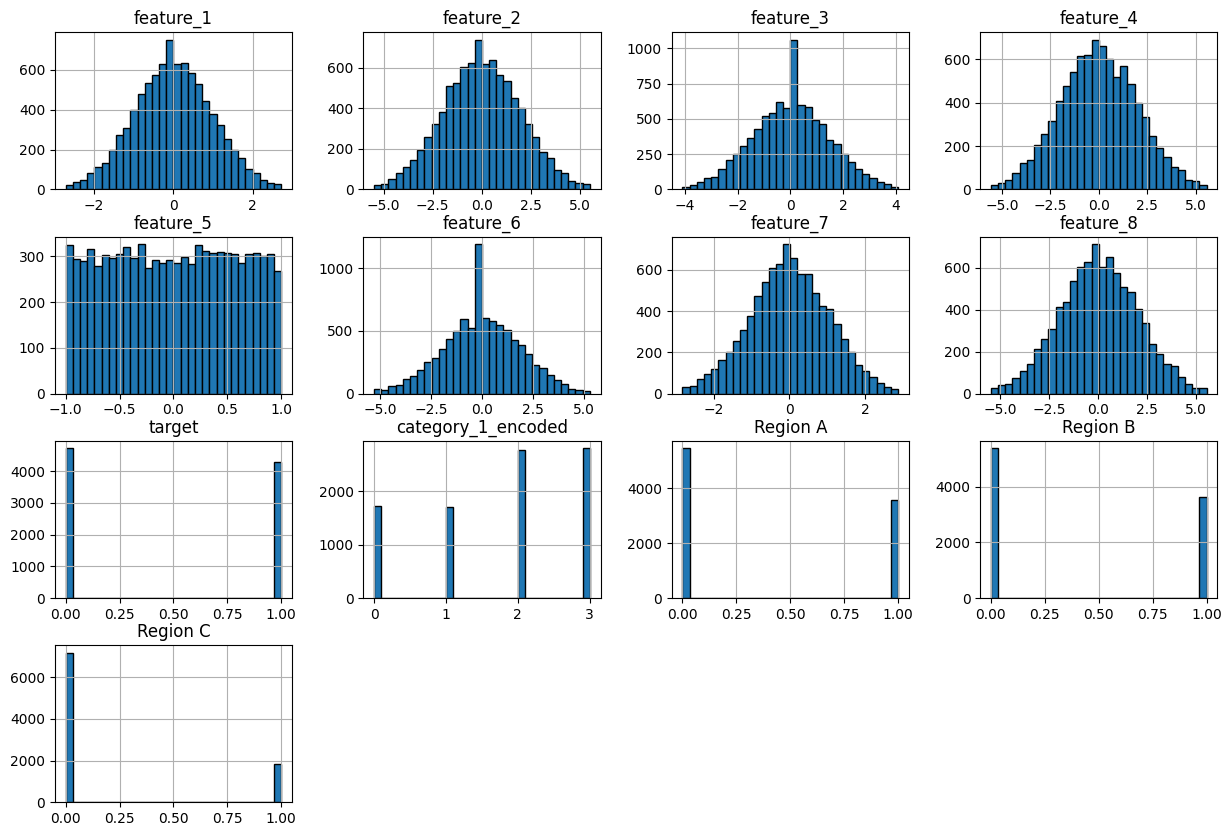

In [ ]:
df_2.hist(bins = 30, figsize=(15,10), edgecolor = 'black')
plt.show()

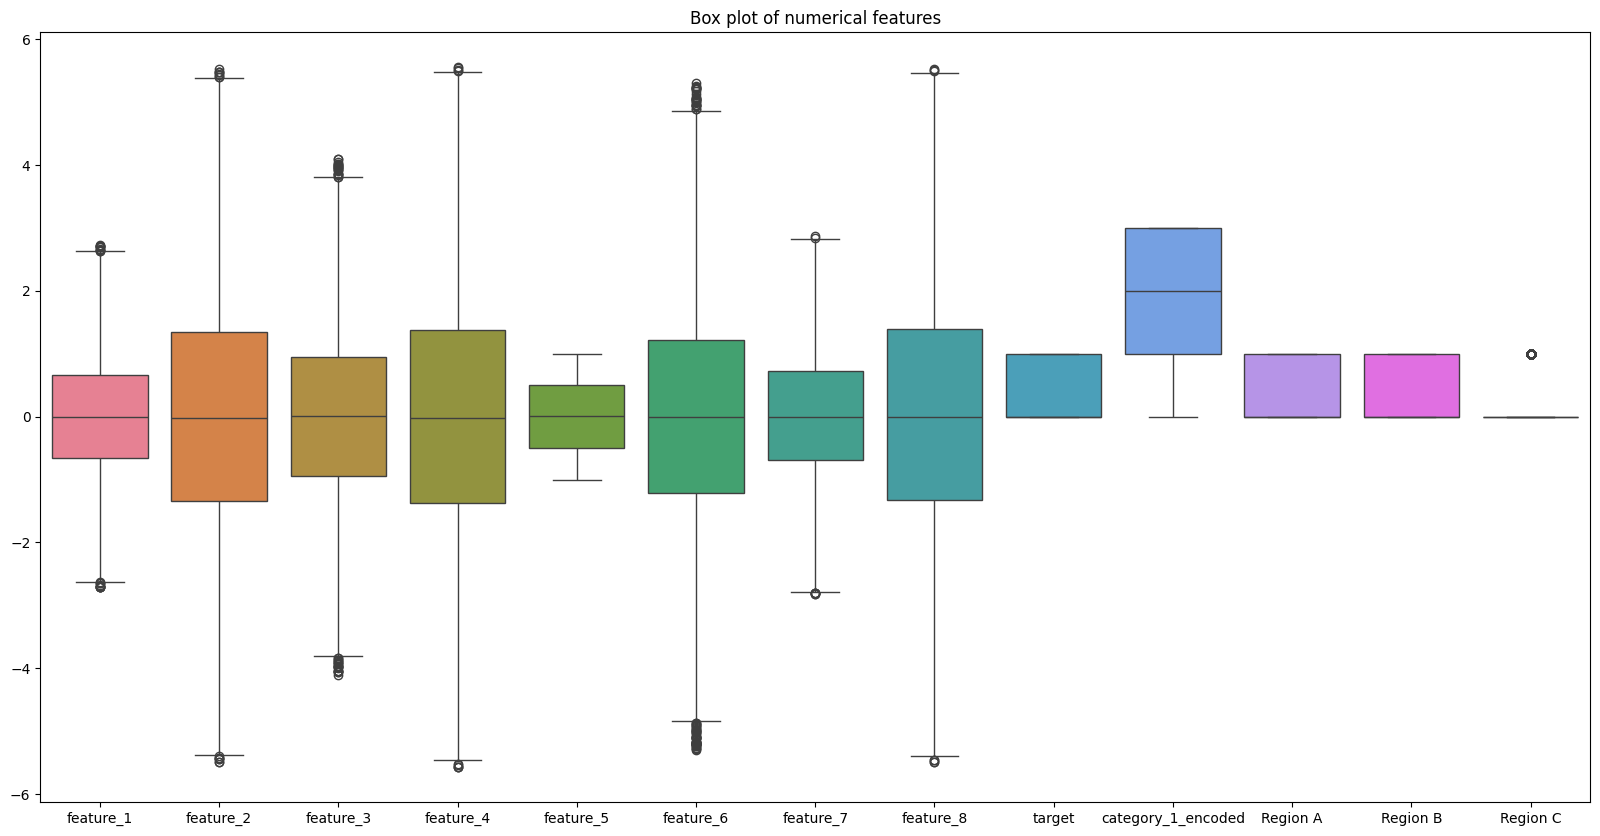

In [ ]:
#Box plot of distribution of numerical features
plt.figure(figsize=(20,10))
sns.boxplot(data=numerical_feas)
plt.title('Box plot of numerical features')
plt.show()

In [ ]:
corr_matrix = df_2.corr()
corr_matrix

,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,target,category_1_encoded,Region A,Region B,Region C
feature_1,1.000000,0.988146,-0.940411,0.953685,-0.007619,0.000234,-0.005004,0.000782,0.704378,-0.367816,0.007945,0.004429,-0.015040
feature_2,0.988146,1.000000,-0.931900,0.961785,-0.006134,0.001543,-0.003342,0.001857,0.707938,-0.364422,0.006452,0.007418,-0.016868
feature_3,-0.940411,-0.931900,1.000000,-0.917972,0.011946,-0.002115,0.005491,-0.003852,-0.691259,0.355027,-0.009001,-0.007496,0.020058
feature_4,0.953685,0.961785,-0.917972,1.000000,-0.003541,0.005649,-0.000322,0.004529,0.698014,-0.358137,0.006577,0.008024,-0.017758
feature_5,-0.007619,-0.006134,0.011946,-0.003541,1.000000,-0.005303,0.243074,-0.015758,-0.007873,0.010906,-0.011237,-0.005956,0.020897
feature_6,0.000234,0.001543,-0.002115,0.005649,-0.005303,1.000000,0.872284,0.918771,0.005262,-0.019384,-0.000701,-0.003828,0.005514
feature_7,-0.005004,-0.003342,0.005491,-0.000322,0.243074,0.872284,1.000000,0.866412,-0.002218,-0.009689,-0.002490,-0.007720,0.012425
feature_8,0.000782,0.001857,-0.003852,0.004529,-0.015758,0.918771,0.866412,1.000000,0.004361,-0.016854,-0.001503,-0.002065,0.004340
target,0.704378,0.707938,-0.691259,0.698014,-0.007873,0.005262,-0.002218,0.004361,1.000000,-0.314612,-0.000593,0.009458,-0.010799
category_1_encoded,-0.367816,-0.364422,0.355027,-0.358137,0.010906,-0.019384,-0.009689,-0.016854,-0.314612,1.000000,-0.000591,-0.001092,0.002048


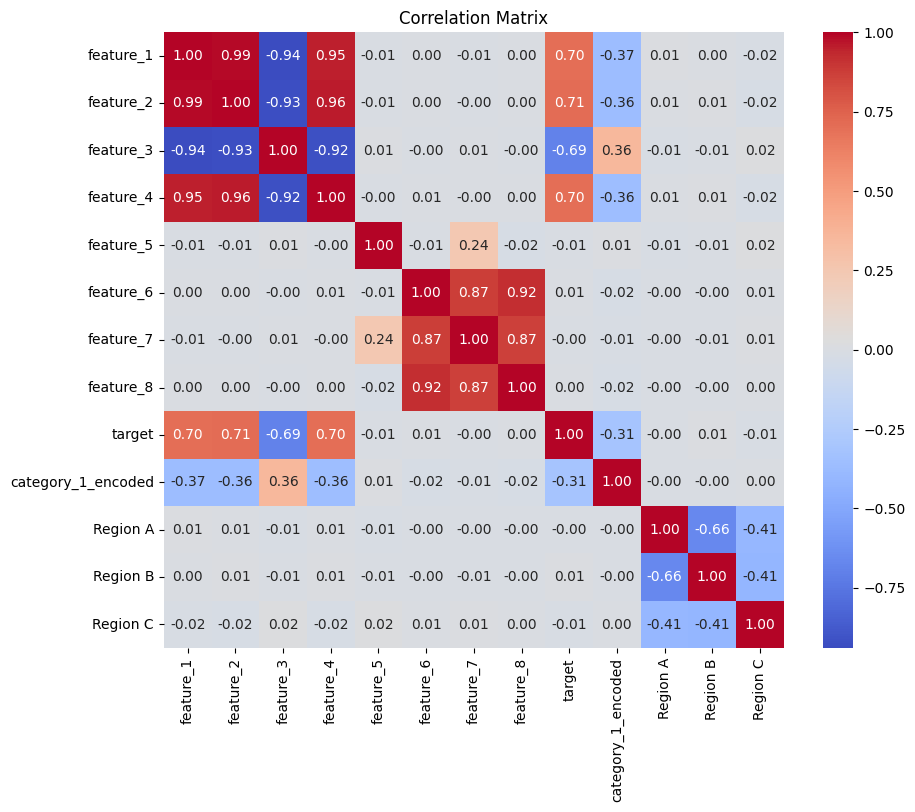

In [ ]:
# plot heatmap that visualizes the correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

In [ ]:
# perform t-tests
from scipy import stats
results = {}
for feature in numerical_feas[:-1]:
    group1 = df_2[df_2['target'] == 1][feature].dropna()
    group0 = df_2[df_2['target'] == 0][feature].dropna()
    t_stat, p_value = stats.ttest_ind(group1, group0)
    results[feature] = {'t_statistic': t_stat, 'p_value': p_value}
results_df_2 = pd.DataFrame(results).T
results_df_2.index.name = 'Feature'
print(results_df_2)

                    t_statistic        p_value
Feature                                       
feature_1             94.129918   0.000000e+00
feature_2             95.081086   0.000000e+00
feature_3            -90.742558   0.000000e+00
feature_4             92.464130   0.000000e+00
feature_5             -0.746804   4.552015e-01
feature_6              0.499102   6.177197e-01
feature_7             -0.210384   8.333725e-01
feature_8              0.413642   6.791461e-01
target                      inf   0.000000e+00
category_1_encoded   -31.439957  5.952144e-206
Region A              -0.056275   9.551243e-01
Region B               0.897181   3.696464e-01
Region C              -1.024417   3.056661e-01


/usr/local/lib/python3.11/dist-packages/scipy/stats/_axis_nan_policy.py:573: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)


In [ ]:
# perform chi-square tests
chi_square_results = {}

contingency_table_1 = pd.crosstab(df_2['category_1'], df_2['target'])
chi2_stat_1, p_value_1, dof_1, expected_1 = stats.chi2_contingency(contingency_table_1)
chi_square_results['category_1'] = {'chi2_statistic': chi2_stat_1, 'p_value': p_value_1}

contingency_table_2 = pd.crosstab(df_2['category_2'], df_2['target'])
chi2_stat_2, p_value_2, dof_2, expected_2 = stats.chi2_contingency(contingency_table_2)
chi_square_results['category_2'] = {'chi2_statistic': chi2_stat_2, 'p_value': p_value_2}

chi_square_results_df = pd.DataFrame.from_dict(chi_square_results, orient='index')
chi_square_results_df.index.name = 'Category'

print(chi_square_results_df)

KeyError: 'category_1'

# IV. FEATURE ENGINEERING

In [ ]:
df_3 = df_2.copy()
# feature engineering
def feature_engineering(df_3):
    df_3['feature_9'] = df_3['feature_1'] * df_3['feature_4']
    return df_3

df_3 = feature_engineering(df_3)
df_3.head()

,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,target,category_1_encoded,Region A,Region B,Region C,feature_9
0,0.496714,1.146509,-0.648521,0.833005,0.784920,-2.209437,-1.300105,-2.242241,1,0,0,0,1,0.413765
1,-0.138264,-0.061846,0.005196,0.403768,0.704674,-2.498565,-1.339227,-1.942298,0,1,1,0,0,-0.055827
2,0.647689,1.395115,-0.764126,1.708266,-0.250029,1.956259,1.190238,1.503559,1,2,0,0,1,1.106424
3,1.523030,2.657560,-2.461653,2.649051,0.882201,3.445638,2.120913,3.409035,1,2,0,1,0,4.034584
4,-0.234153,-0.499391,0.576097,-0.441656,0.610601,0.211425,0.935759,-0.401463,0,1,0,0,1,0.103415


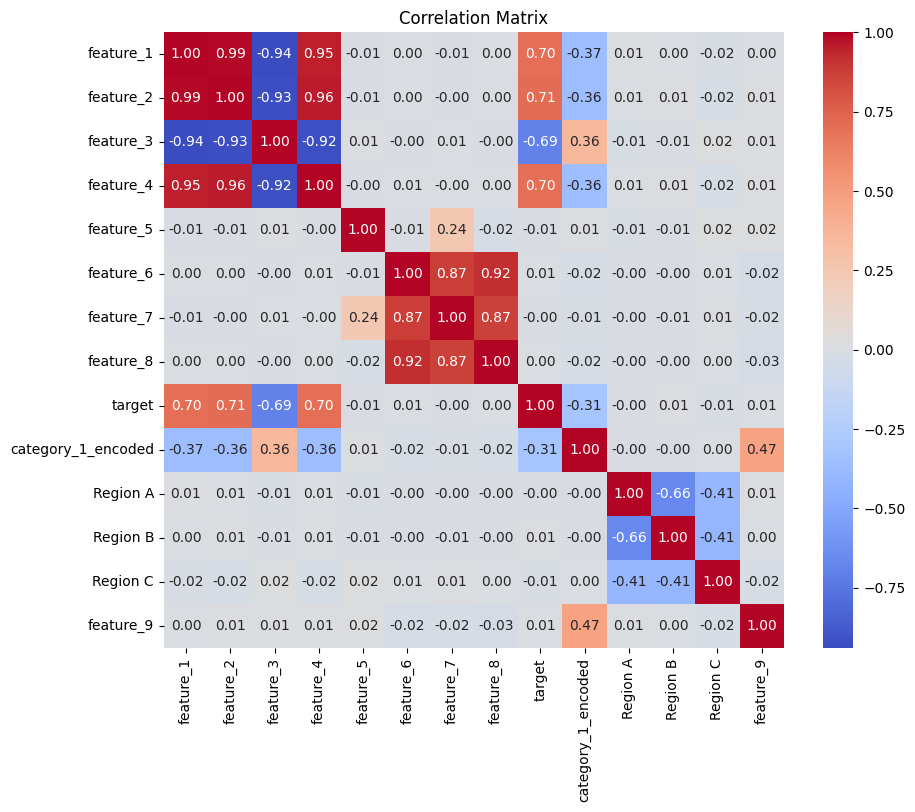

In [ ]:
# plot heatmap that visualize the correlation matrix
correlation_matrix = df_3.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

In [ ]:
# export cleaned dataset with new features
df_3.to_csv('C:\depression analysis\Machine Learning\final project\cleaned_dataset with new features.csv')

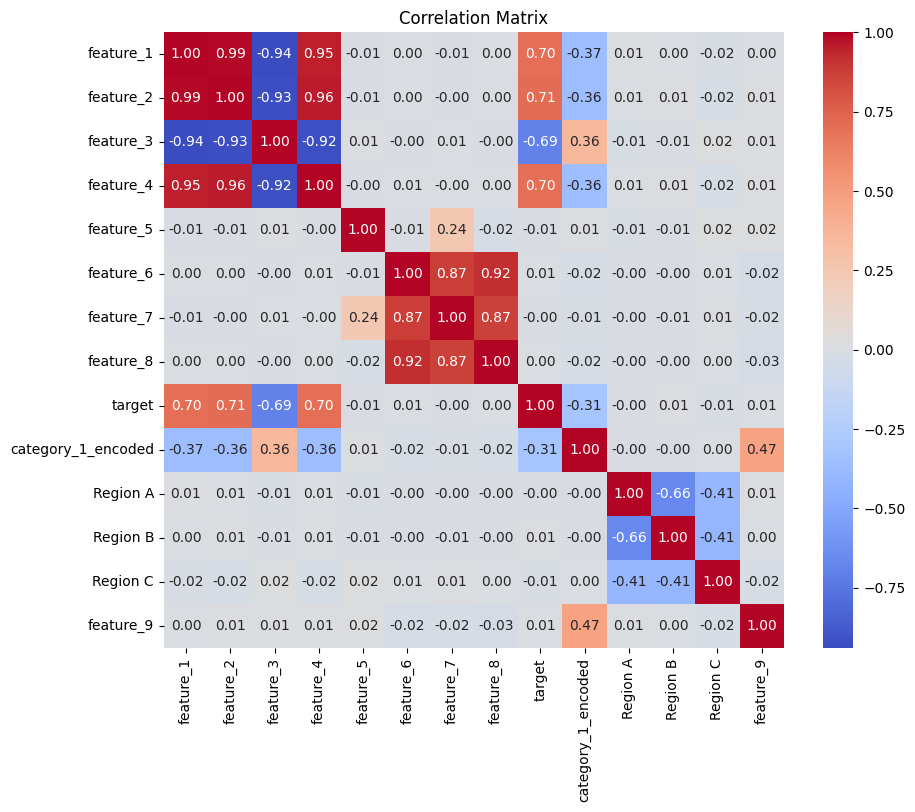

In [ ]:
# plot heatmap that visualize the correlation matrix
correlation_matrix = df_3.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

In [ ]:
#feature scaling
scaler = MinMaxScaler()
for feature in df_3:
    df_3[feature] = scaler.fit_transform(df_3[[feature]])

print(df_3.head())

   feature_1  feature_2  feature_3  feature_4  feature_5  feature_6  \
0   0.590734   0.602870   0.421387   0.575676   0.892487   0.291691   
1   0.473855   0.493050   0.501098   0.537082   0.852358   0.264397   
2   0.618523   0.625464   0.407291   0.654372   0.374936   0.684934   
3   0.779645   0.740199   0.200304   0.738960   0.941135   0.825531   
4   0.456204   0.453284   0.570710   0.461068   0.805315   0.520221   

   feature_7  feature_8  target  category_1_encoded  Region A  Region B  \
0   0.266829   0.294740     1.0            0.000000       0.0       0.0   
1   0.259961   0.321959     0.0            0.333333       1.0       0.0   
2   0.704035   0.634662     1.0            0.666667       0.0       0.0   
3   0.867424   0.807579     1.0            0.666667       0.0       1.0   
4   0.659358   0.461786     0.0            0.333333       0.0       0.0   

   Region C  feature_9  
0       1.0   0.091154  
1       0.0   0.061612  
2       1.0   0.134728  
3       0.0   0.318937

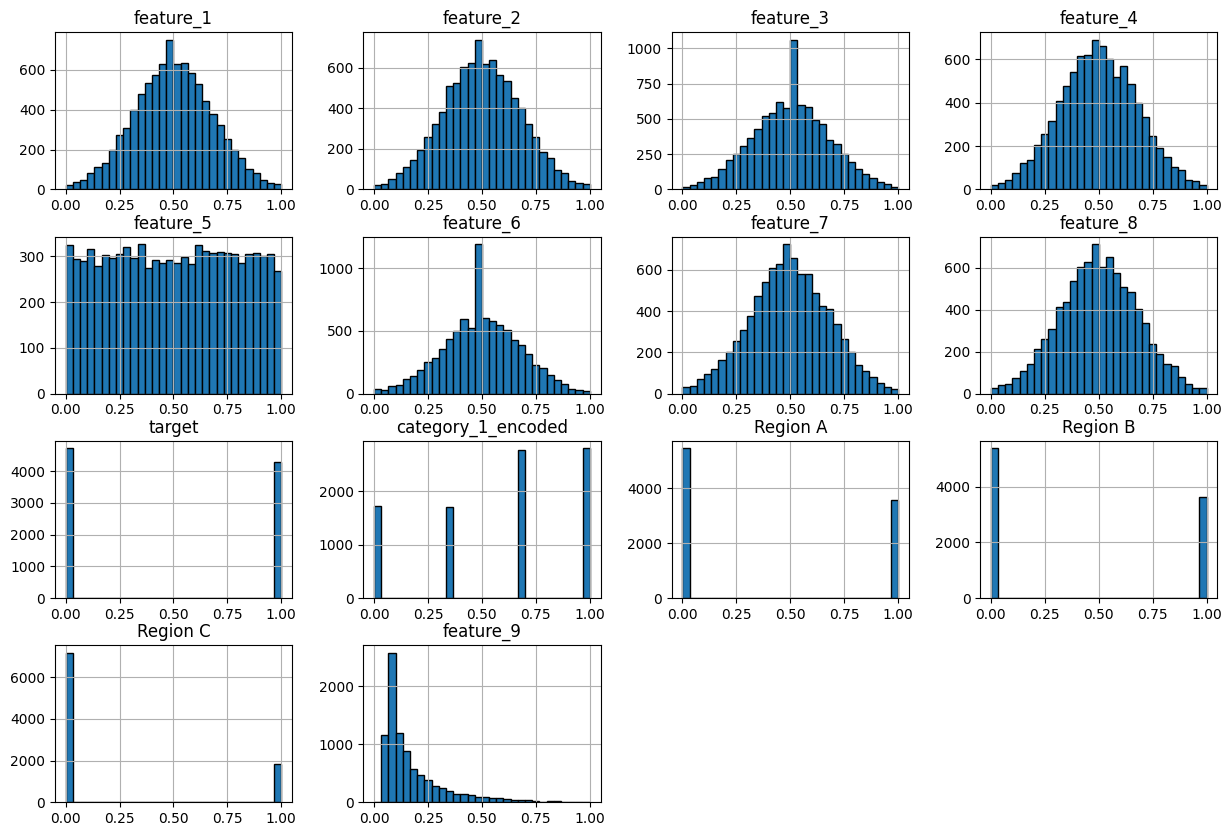

In [ ]:
df_3.hist(bins = 30, figsize=(15,10), edgecolor = 'black')
plt.show()

# V. **MODELING**

In [ ]:
df_3.head()

,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,target,category_1_encoded,Region A,Region B,Region C,feature_9
0,0.590734,0.602870,0.421387,0.575676,0.892487,0.291691,0.266829,0.294740,1.0,0.000000,0.0,0.0,1.0,0.091154
1,0.473855,0.493050,0.501098,0.537082,0.852358,0.264397,0.259961,0.321959,0.0,0.333333,1.0,0.0,0.0,0.061612
2,0.618523,0.625464,0.407291,0.654372,0.374936,0.684934,0.704035,0.634662,1.0,0.666667,0.0,0.0,1.0,0.134728
3,0.779645,0.740199,0.200304,0.738960,0.941135,0.825531,0.867424,0.807579,1.0,0.666667,0.0,1.0,0.0,0.318937
4,0.456204,0.453284,0.570710,0.461068,0.805315,0.520221,0.659358,0.461786,0.0,0.333333,0.0,0.0,1.0,0.071630


In [ ]:
X = df_3.drop('target', axis=1)
y = df_3['target']

In [ ]:
X.head()

,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,category_1_encoded,Region A,Region B,Region C,feature_9
0,0.590734,0.602870,0.421387,0.575676,0.892487,0.291691,0.266829,0.294740,0.000000,0.0,0.0,1.0,0.091154
1,0.473855,0.493050,0.501098,0.537082,0.852358,0.264397,0.259961,0.321959,0.333333,1.0,0.0,0.0,0.061612
2,0.618523,0.625464,0.407291,0.654372,0.374936,0.684934,0.704035,0.634662,0.666667,0.0,0.0,1.0,0.134728
3,0.779645,0.740199,0.200304,0.738960,0.941135,0.825531,0.867424,0.807579,0.666667,0.0,1.0,0.0,0.318937
4,0.456204,0.453284,0.570710,0.461068,0.805315,0.520221,0.659358,0.461786,0.333333,0.0,0.0,1.0,0.071630


In [ ]:
y.head()

,target
0,1.0
1,0.0
2,1.0
3,1.0
4,0.0


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [ ]:
print(len(X_train))
print(len(X_test))

7200
1800


In [ ]:
#def evaluate_model(model, param_grid, X_train, y_train, X_test, y_test):

    # GridSearchCV for hyperparameter tuning
    #grid_search = GridSearchCV(estimator=model, param_grid=param_grid, cv=5, scoring='accuracy')
    #grid_search.fit(X_train, y_train)

    # Training the model with the best parameters
    #best_model = grid_search.best_estimator_

    # Predictions
    #predictions = best_model.predict(X_test)

    # Best parameters
    #best_parameters = grid_search.best_params_
    #print("Best Parameters:", best_parameters)

    #print("Classification Report:")
    #print(classification_report(y_test, predictions))

    # Evaluation
    #conf_matrix = confusion_matrix(y_test, predictions)

    # visualization of Confusion Matrix
    #plt.figure(figsize=(6, 4))
    #sns.heatmap(pd.DataFrame(conf_matrix), annot=True, cmap="YlGnBu", fmt='g')
    #plt.title('Confusion matrix')
    #plt.ylabel('Actual label')
    #plt.xlabel('Predicted label')
    #plt.show()

    # ROC curve and AUC
    #y_probs = best_model.predict_proba(X_test)[:, 1]  # Get probabilities for the positive class (class 1)
    #fpr, tpr, thresholds = roc_curve(y_test, y_probs)
    #roc_auc = auc(fpr, tpr)

    #plt.figure(figsize=(8, 6))
    #plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
    #plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--') #Dashed line represents random guessing
    #plt.xlim([0.0, 1.0])
    #plt.ylim([0.0, 1.05])
    #plt.xlabel('False Positive Rate')
    #plt.ylabel('True Positive Rate')
    #plt.title('Receiver Operating Characteristic (ROC)')
    #plt.legend(loc="lower right")
    #plt.show()

    #print(f"Random Forest AUC: {roc_auc}")

    # cross validation
    #kfold = KFold(n_splits=5, shuffle=True, random_state=42)  # Or StratifiedKFold for classification
    #kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    #cv_scores = cross_val_score(best_model, X_train, y_train, cv=kfold, scoring='accuracy')  # Use X_train!

    #print("\nCross-validation scores (using cross_val_score):", cv_scores)
    #print("Mean cross-validation score:", cv_scores.mean())
    #print("Standard deviation of scores:", cv_scores.std())

    #plt.figure(figsize=(8, 6))
    #sns.boxplot(y=cv_scores)  # Create a box plot
    #plt.title("Cross-Validation Scores")
    #plt.ylabel("Accuracy")  # Or your chosen metric
    #plt.show()

    #return best_model

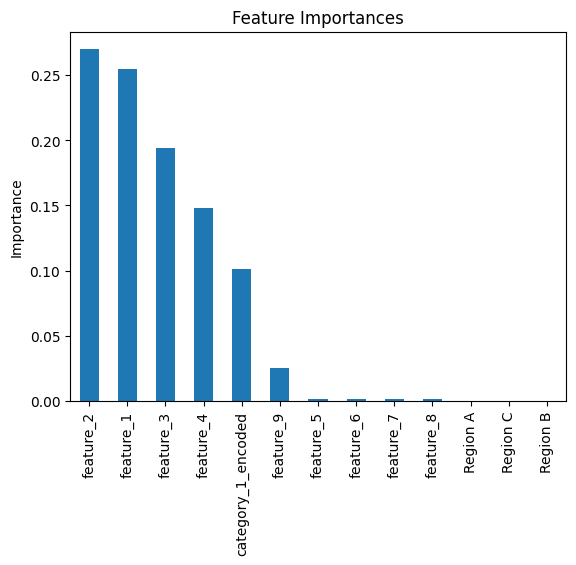

              precision    recall  f1-score   support

         0.0       0.86      0.90      0.88       947
         1.0       0.89      0.84      0.87       853

    accuracy                           0.88      1800
   macro avg       0.88      0.87      0.87      1800
weighted avg       0.88      0.88      0.88      1800

[[857  90]
 [134 719]]


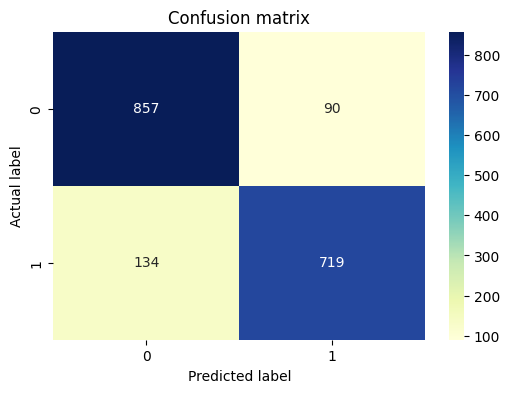

0.8755555555555555


In [ ]:
# default Random Forest
rf_default = RandomForestClassifier(n_estimators=500, max_leaf_nodes=16, random_state=42)
rf_default.fit(X_train, y_train)

y_pred_rf = rf_default.predict(X_test)

#feature importance
feature_importances = rf_default.feature_importances_
forest_importances = pd.Series(feature_importances, index=X_train.columns)
forest_importances.sort_values(ascending=False, inplace=True)
forest_importances.plot(kind='bar', title='Feature Importances')
plt.ylabel('Importance')
plt.show()


print(classification_report(y_test, y_pred_rf))
#print(feature_importances)

print(confusion_matrix(y_test, y_pred_rf))
plt.figure(figsize=(6,4))
sns.heatmap(pd.DataFrame(confusion_matrix(y_test, y_pred_rf)), annot=True, cmap="YlGnBu", fmt='g')
plt.title('Confusion matrix')
plt.ylabel('Actual label')
plt.xlabel('Predicted label')
plt.show()

print(accuracy_score(y_test, y_pred_rf))





# confusion matrix
#cm_default = confusion_matrix(y_test, y_test_pred)
#plt.figure(figsize=(8, 6))
#sns.heatmap(cm_default, annot=True, fmt="d", cmap="Blues", cbar=False,
            #xticklabels=np.unique(y), yticklabels=np.unique(y)) # xticklabels and yticklabels added
#plt.xlabel("Predicted Label")
#plt.ylabel("True Label")
#plt.title("Confusion Matrix")
#plt.show()

# ROC curve and AUC
#y_probs = rf_default.predict_proba(X_test)[:, 1]  # Get probabilities for the positive class (class 1)
#fpr, tpr, thresholds = roc_curve(y_test, y_probs)
#roc_auc = auc(fpr, tpr)

#plt.figure(figsize=(8, 6))
#plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
#plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--') #Dashed line represents random guessing
#plt.xlim([0.0, 1.0])
#plt.ylim([0.0, 1.05])
#plt.xlabel('False Positive Rate')
#plt.ylabel('True Positive Rate')
#plt.title('Receiver Operating Characteristic (ROC)')
#plt.legend(loc="lower right")
#plt.show()
#print(f"Random Forest AUC: {roc_auc}")

# cross validation
#kfold = KFold(n_splits=5, shuffle=True, random_state=42)  # Or StratifiedKFold for classification
#kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

#cv_scores = cross_val_score(rf_default, X_train, y_train, cv=kfold, scoring='accuracy')  # Use X_train only hehe

#print("\nCross-validation scores (using cross_val_score):", cv_scores)
#print("Mean cross-validation score:", cv_scores.mean())
#print("Standard deviation of scores:", cv_scores.std())

#lt.figure(figsize=(8, 6))
#sns.boxplot(y=cv_scores)  # create a box plot
#plt.title("Cross-Validation Scores")
#plt.ylabel("Accuracy")
#plt.show()

#explainer = shap.Explainer(rf_default, X_train)
#shap_values = explainer.shap_values(X_train)
#shap.summary_plot(shap_values, X_train)

#explainer = shap.Explainer(rf_default, X_test)
#shap_values = explainer.shap_values(X_test)
#shap.summary_plot(shap_values, X_test)
#shap.summary_plot(shap_values[0], X_test)

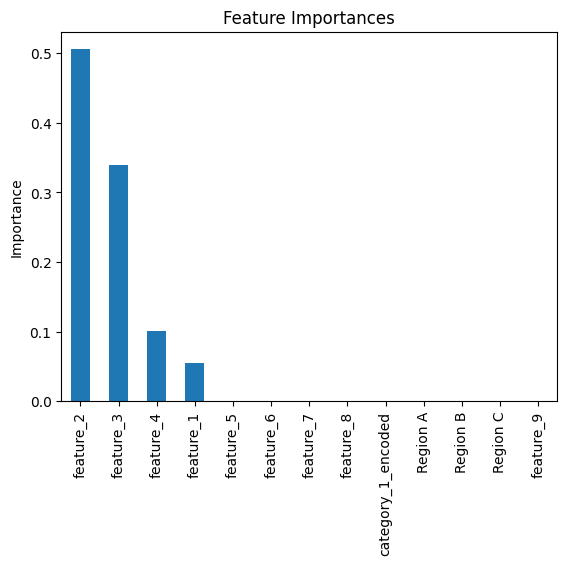

              precision    recall  f1-score   support

         0.0       0.85      0.88      0.87       947
         1.0       0.86      0.83      0.85       853

    accuracy                           0.86      1800
   macro avg       0.86      0.86      0.86      1800
weighted avg       0.86      0.86      0.86      1800

[[836 111]
 [143 710]]


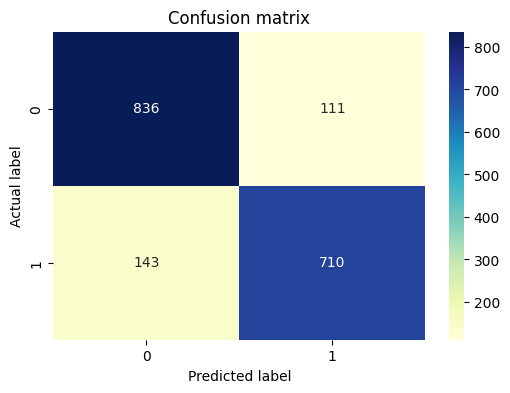

0.8588888888888889
[0.85486111 0.85833333 0.86736111 0.87083333 0.85416667]
0.8611111111111113
0.00676147858035452


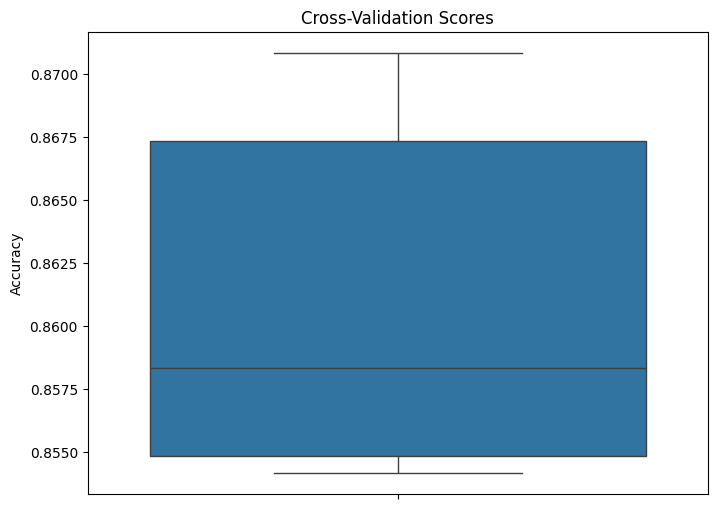

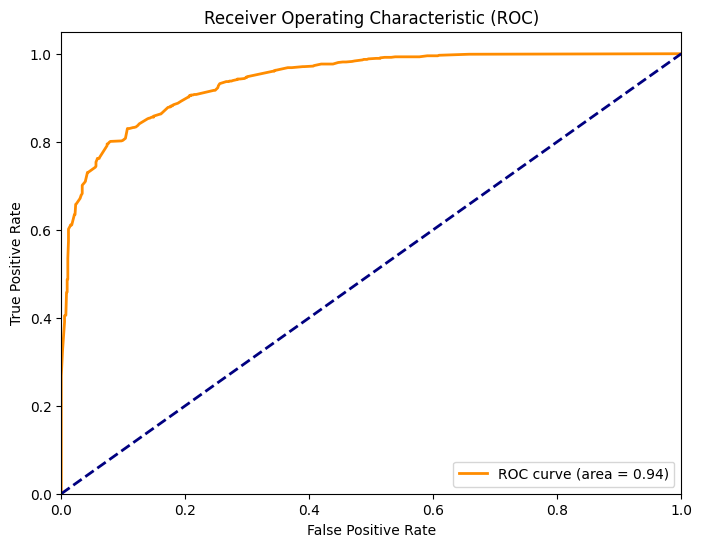

Random Forest AUC: 0.9410744858509195


In [67]:
#Gradient Boosting
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import cross_val_score, KFold, StratifiedKFold
from sklearn import metrics
from sklearn.metrics import roc_auc_score, roc_curve

gb_default = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1,max_depth=1,random_state=42)
gb_default.fit(X_train,y_train)
gb_default.score(X_test,y_test)

y_pred_gb = gb_default.predict(X_test)

#feature importance
feature_importances = gb_default.feature_importances_
gb_importances = pd.Series(feature_importances, index=X_train.columns)
gb_importances.sort_values(ascending=False, inplace=True)
gb_importances.plot(kind='bar', title='Feature Importances')
plt.ylabel('Importance')
plt.show()

print(classification_report(y_test, y_pred_gb))

#confusion matrix
print(confusion_matrix(y_test, y_pred_gb))
plt.figure(figsize=(6,4))
sns.heatmap(pd.DataFrame(confusion_matrix(y_test, y_pred_gb)), annot=True, cmap="YlGnBu", fmt='g')
plt.title('Confusion matrix')
plt.ylabel('Actual label')
plt.xlabel('Predicted label')
plt.show()

#accuracy
print(accuracy_score(y_test, y_pred_gb))

#cross-validation
gb_scores = cross_val_score(gb_default,X_train,y_train,cv=5)
print(gb_scores)
print(gb_scores.mean())
print(gb_scores.std())
plt.figure(figsize=(8,6))
sns.boxplot(y=gb_scores)
plt.title("Cross-Validation Scores")
plt.ylabel("Accuracy")
plt.show()


#ROC-AUC curve
y_probs = gb_default.predict_proba(X_test)[:, 1]  # Get probabilities for the positive class (class 1)
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.show()
print(f"Random Forest AUC: {roc_auc}")
